<a href="https://colab.research.google.com/github/M-Mag25/Group-Work-Project-1-/blob/main/GWP_1_Derivative_Pricing_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 620 Derivative Pricing – Group Work Project 1 (Student Group 13544)

In [26]:
# MScFE 620 Derivative Pricing - Group Work Project 1
# Team Members: A, B, C
# Date: May 2025

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set precision and display options
pd.set_option('display.precision', 2)

In [27]:
# Parameters
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0
N = 100  # steps
dt = T / N
u = np.exp(sigma * np.sqrt(dt))
d = 1 / u
p = (np.exp(r * dt) - d) / (u - d)  # risk-neutral probability

In [28]:
def binomial_tree_european(S0, K, T, r, sigma, N, option_type='call'):
    """Price European option using binomial tree."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Asset prices at maturity
    S = np.zeros(N+1)
    for i in range(N+1):
        S[i] = S0 * (u ** (N-i)) * (d ** i)  # i down moves

    # Option payoff at maturity
    if option_type == 'call':
        V = np.maximum(S - K, 0)
    else:
        V = np.maximum(K - S, 0)

    # Backward induction
    for j in range(N-1, -1, -1):
        for i in range(j+1):
            V[i] = discount * (p * V[i] + (1-p) * V[i+1])
    return V[0]

def binomial_tree_american(S0, K, T, r, sigma, N, option_type='call'):
    """Price American option using binomial tree."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Asset prices at each node (we'll compute on the fly)
    # We'll store option values in a 2D array
    V = np.zeros((N+1, N+1))  # V[step][i] where i is number of down moves
    S = np.zeros((N+1, N+1))

    # Initialize asset prices at maturity
    for i in range(N+1):
        S[N][i] = S0 * (u ** (N-i)) * (d ** i)
        if option_type == 'call':
            V[N][i] = max(S[N][i] - K, 0)
        else:
            V[N][i] = max(K - S[N][i], 0)

    # Backward induction
    for j in range(N-1, -1, -1):
        for i in range(j+1):
            S[j][i] = S0 * (u ** (j-i)) * (d ** i)
            continuation = discount * (p * V[j+1][i] + (1-p) * V[j+1][i+1])
            if option_type == 'call':
                exercise = max(S[j][i] - K, 0)
            else:
                exercise = max(K - S[j][i], 0)
            V[j][i] = max(continuation, exercise)
    return V[0][0]

In [29]:
eur_call = binomial_tree_european(S0, K, T, r, sigma, N, 'call')
eur_put = binomial_tree_european(S0, K, T, r, sigma, N, 'put')

print(f"European Call Price: {eur_call:.2f}")
print(f"European Put Price: {eur_put:.2f}")

European Call Price: 10.43
European Put Price: 5.55


In [30]:
# Compute Delta using one-step tree
dt1 = T / N
u1 = np.exp(sigma * np.sqrt(dt1))
d1 = 1 / u1
p1 = (np.exp(r * dt1) - d1) / (u1 - d1)
discount1 = np.exp(-r * dt1)

S_up = S0 * u1
S_down = S0 * d1

# Option values at next step (using full tree for accuracy? Actually we need the values at the first step nodes.
# We can compute them by building a tree from those nodes. Simpler: use the same tree function but with S0 replaced.
# For efficiency, we can compute using the binomial tree function with N-1 steps from the new nodes.
def option_value_at_node(S, remaining_steps, option_type='call', american=False):
    if american:
        return binomial_tree_american(S, K, T - (T/N), r, sigma, remaining_steps, option_type)
    else:
        return binomial_tree_european(S, K, T - (T/N), r, sigma, remaining_steps, option_type)

V_up_call = option_value_at_node(S_up, N-1, 'call', american=False)
V_down_call = option_value_at_node(S_down, N-1, 'call', american=False)
delta_call = (V_up_call - V_down_call) / (S_up - S_down)

V_up_put = option_value_at_node(S_up, N-1, 'put', american=False)
V_down_put = option_value_at_node(S_down, N-1, 'put', american=False)
delta_put = (V_up_put - V_down_put) / (S_up - S_down)

print(f"European Call Delta: {delta_call:.4f}")
print(f"European Put Delta: {delta_put:.4f}")

European Call Delta: 0.6365
European Put Delta: -0.3635


In [31]:
sigma_new = 0.25
eur_call_highvol = binomial_tree_european(S0, K, T, r, sigma_new, N, 'call')
eur_put_highvol = binomial_tree_european(S0, K, T, r, sigma_new, N, 'put')

print(f"European Call at sigma=20%: {eur_call:.2f}, at 25%: {eur_call_highvol:.2f}, change: {eur_call_highvol - eur_call:.2f}")
print(f"European Put at sigma=20%: {eur_put:.2f}, at 25%: {eur_put_highvol:.2f}, change: {eur_put_highvol - eur_put:.2f}")

European Call at sigma=20%: 10.43, at 25%: 12.31, change: 1.88
European Put at sigma=20%: 5.55, at 25%: 7.43, change: 1.88


In [32]:
am_call = binomial_tree_american(S0, K, T, r, sigma, N, 'call')
am_put = binomial_tree_american(S0, K, T, r, sigma, N, 'put')

print(f"American Call Price: {am_call:.2f}")
print(f"American Put Price: {am_put:.2f}")

American Call Price: 10.43
American Put Price: 6.08


In [33]:
V_up_am_call = option_value_at_node(S_up, N-1, 'call', american=True)
V_down_am_call = option_value_at_node(S_down, N-1, 'call', american=True)
delta_am_call = (V_up_am_call - V_down_am_call) / (S_up - S_down)

V_up_am_put = option_value_at_node(S_up, N-1, 'put', american=True)
V_down_am_put = option_value_at_node(S_down, N-1, 'put', american=True)
delta_am_put = (V_up_am_put - V_down_am_put) / (S_up - S_down)

print(f"American Call Delta: {delta_am_call:.4f}")
print(f"American Put Delta: {delta_am_put:.4f}")

American Call Delta: 0.6365
American Put Delta: -0.4116


In [34]:
am_call_highvol = binomial_tree_american(S0, K, T, r, sigma_new, N, 'call')
am_put_highvol = binomial_tree_american(S0, K, T, r, sigma_new, N, 'put')

print(f"American Call at sigma=20%: {am_call:.2f}, at 25%: {am_call_highvol:.2f}, change: {am_call_highvol - am_call:.2f}")
print(f"American Put at sigma=20%: {am_put:.2f}, at 25%: {am_put_highvol:.2f}, change: {am_put_highvol - am_put:.2f}")

American Call at sigma=20%: 10.43, at 25%: 12.31, change: 1.88
American Put at sigma=20%: 6.08, at 25%: 7.96, change: 1.88


In [35]:
left = eur_call + K * np.exp(-r * T)
right = eur_put + S0
print(f"Call + K e^(-rT) = {left:.4f}")
print(f"Put + S0 = {right:.4f}")
print(f"Difference: {left - right:.6f}")

Call + K e^(-rT) = 105.5536
Put + S0 = 105.5536
Difference: -0.000000


In [36]:
print(f"European Call: {eur_call:.2f}, American Call: {am_call:.2f}, Difference: {am_call - eur_call:.4f}")

European Call: 10.43, American Call: 10.43, Difference: 0.0000


In [37]:
print(f"European Put: {eur_put:.2f}, American Put: {am_put:.2f}, Difference: {am_put - eur_put:.4f}")

European Put: 5.55, American Put: 6.08, Difference: 0.5288


In [38]:
def trinomial_tree_european(S0, K, T, r, sigma, N, option_type='call'):
    """Price European option using trinomial tree."""
    dt = T / N
    dx = sigma * np.sqrt(3*dt)  # typical choice
    u = np.exp(dx)
    d = 1/u
    pu = 1/6 + (r - sigma**2/2) * np.sqrt(dt/(12*sigma**2))
    pd = 1/6 - (r - sigma**2/2) * np.sqrt(dt/(12*sigma**2))
    pm = 2/3
    # Ensure probabilities are between 0 and 1 (adjust if needed)
    discount = np.exp(-r * dt)

    # Asset prices at maturity
    S = np.zeros(2*N+1)
    for i in range(2*N+1):
        S[i] = S0 * (u ** (N - i))  # i down moves relative to center? Actually index from -N to N
    # We'll use a simpler approach: build a 2D array for nodes
    # Instead, we can do backward induction with a 2D array of size (N+1) x (2N+1)
    V = np.zeros((N+1, 2*N+1))
    # At maturity
    for j in range(2*N+1):
        S_maturity = S0 * (u ** (N - j))
        if option_type == 'call':
            V[N][j] = max(S_maturity - K, 0)
        else:
            V[N][j] = max(K - S_maturity, 0)
    # Backward
    for i in range(N-1, -1, -1):
        for j in range(2*i+1):
            S_curr = S0 * (u ** (i - j))
            # Values at next step: up (j), middle (j+1), down (j+2) because index shift
            V[i][j] = discount * (pu * V[i+1][j] + pm * V[i+1][j+1] + pd * V[i+1][j+2])
    return V[0][0]

def trinomial_tree_american(S0, K, T, r, sigma, N, option_type='call'):
    """Price American option using trinomial tree."""
    dt = T / N
    dx = sigma * np.sqrt(3*dt)
    u = np.exp(dx)
    d = 1/u
    pu = 1/6 + (r - sigma**2/2) * np.sqrt(dt/(12*sigma**2))
    pd = 1/6 - (r - sigma**2/2) * np.sqrt(dt/(12*sigma**2))
    pm = 2/3
    discount = np.exp(-r * dt)

    V = np.zeros((N+1, 2*N+1))
    # At maturity
    for j in range(2*N+1):
        S_maturity = S0 * (u ** (N - j))
        if option_type == 'call':
            V[N][j] = max(S_maturity - K, 0)
        else:
            V[N][j] = max(K - S_maturity, 0)
    # Backward
    for i in range(N-1, -1, -1):
        for j in range(2*i+1):
            S_curr = S0 * (u ** (i - j))
            continuation = discount * (pu * V[i+1][j] + pm * V[i+1][j+1] + pd * V[i+1][j+2])
            if option_type == 'call':
                exercise = max(S_curr - K, 0)
            else:
                exercise = max(K - S_curr, 0)
            V[i][j] = max(continuation, exercise)
    return V[0][0]

In [39]:
strikes = [90, 95, 100, 105, 110]
eur_call_prices = []
eur_put_prices = []

for K_val in strikes:
    call_price = trinomial_tree_european(S0, K_val, T, r, sigma, 100, 'call')
    put_price = trinomial_tree_european(S0, K_val, T, r, sigma, 100, 'put')
    eur_call_prices.append(call_price)
    eur_put_prices.append(put_price)

df_euro = pd.DataFrame({
    'Strike': strikes,
    'Moneyness (K/S0)': [k/S0 for k in strikes],
    'Call Price': eur_call_prices,
    'Put Price': eur_put_prices
})
print("European Options (Trinomial Tree)")
print(df_euro.round(2))

European Options (Trinomial Tree)
   Strike  Moneyness (K/S0)  Call Price  Put Price
0      90              0.90       16.69       2.30
1      95              0.95       13.35       3.72
2     100              1.00       10.43       5.55
3     105              1.05        8.03       7.91
4     110              1.10        6.04      10.68


In [40]:
am_call_prices = []
am_put_prices = []
for K_val in strikes:
    call_price = trinomial_tree_american(S0, K_val, T, r, sigma, 100, 'call')
    put_price = trinomial_tree_american(S0, K_val, T, r, sigma, 100, 'put')
    am_call_prices.append(call_price)
    am_put_prices.append(put_price)

df_am = pd.DataFrame({
    'Strike': strikes,
    'Moneyness (K/S0)': [k/S0 for k in strikes],
    'American Call': am_call_prices,
    'American Put': am_put_prices
})
print("\nAmerican Options (Trinomial Tree)")
print(df_am.round(2))


American Options (Trinomial Tree)
   Strike  Moneyness (K/S0)  American Call  American Put
0      90              0.90          16.69          2.46
1      95              0.95          13.35          4.01
2     100              1.00          10.43          6.07
3     105              1.05           8.03          8.74
4     110              1.10           6.04         11.96


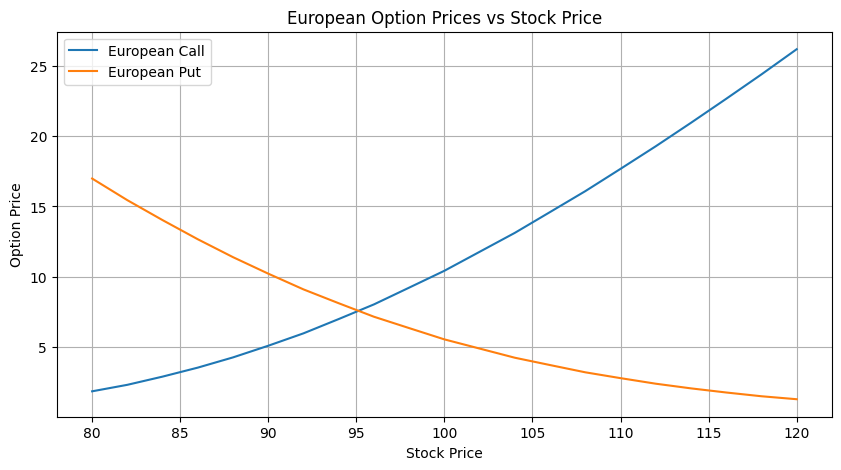

In [41]:
S_range = np.arange(80, 121, 2)
eur_call_S = []
eur_put_S = []
for S in S_range:
    eur_call_S.append(binomial_tree_european(S, K, T, r, sigma, N, 'call'))
    eur_put_S.append(binomial_tree_european(S, K, T, r, sigma, N, 'put'))

plt.figure(figsize=(10,5))
plt.plot(S_range, eur_call_S, label='European Call')
plt.plot(S_range, eur_put_S, label='European Put')
plt.xlabel('Stock Price')
plt.ylabel('Option Price')
plt.title('European Option Prices vs Stock Price')
plt.legend()
plt.grid(True)
plt.show()

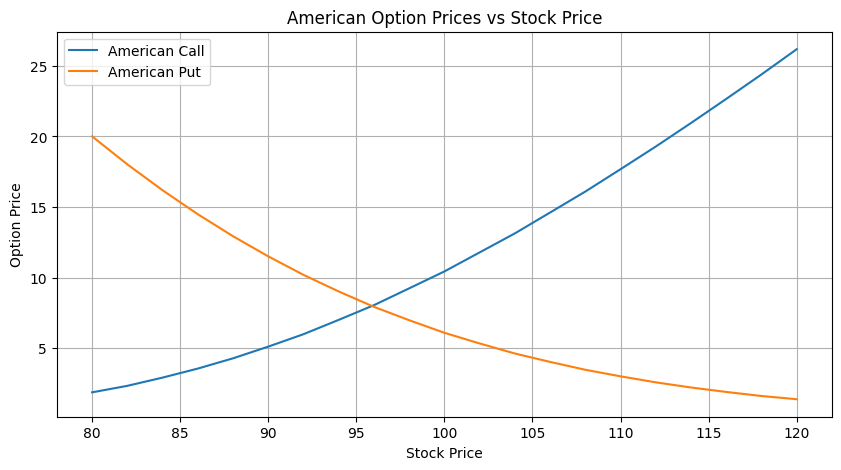

In [42]:
am_call_S = []
am_put_S = []
for S in S_range:
    am_call_S.append(binomial_tree_american(S, K, T, r, sigma, N, 'call'))
    am_put_S.append(binomial_tree_american(S, K, T, r, sigma, N, 'put'))

plt.figure(figsize=(10,5))
plt.plot(S_range, am_call_S, label='American Call')
plt.plot(S_range, am_put_S, label='American Put')
plt.xlabel('Stock Price')
plt.ylabel('Option Price')
plt.title('American Option Prices vs Stock Price')
plt.legend()
plt.grid(True)
plt.show()

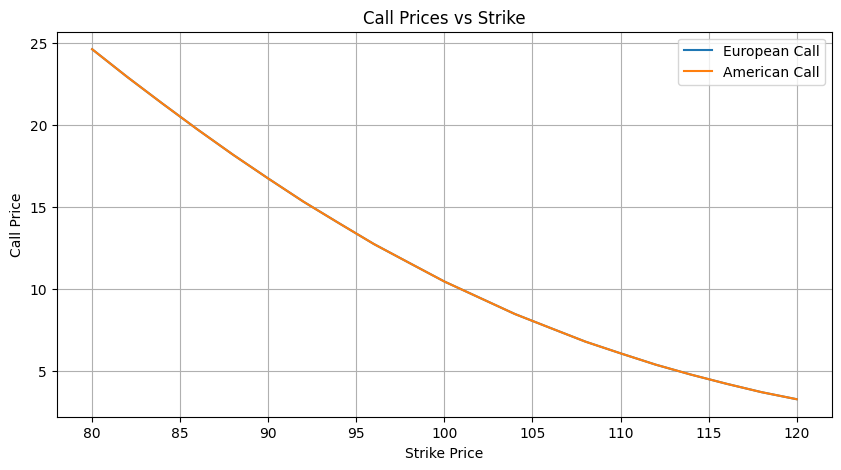

In [43]:
strike_range = np.arange(80, 121, 2)
eur_call_K = []
am_call_K = []
for K_val in strike_range:
    eur_call_K.append(binomial_tree_european(S0, K_val, T, r, sigma, N, 'call'))
    am_call_K.append(binomial_tree_american(S0, K_val, T, r, sigma, N, 'call'))

plt.figure(figsize=(10,5))
plt.plot(strike_range, eur_call_K, label='European Call')
plt.plot(strike_range, am_call_K, label='American Call')
plt.xlabel('Strike Price')
plt.ylabel('Call Price')
plt.title('Call Prices vs Strike')
plt.legend()
plt.grid(True)
plt.show()

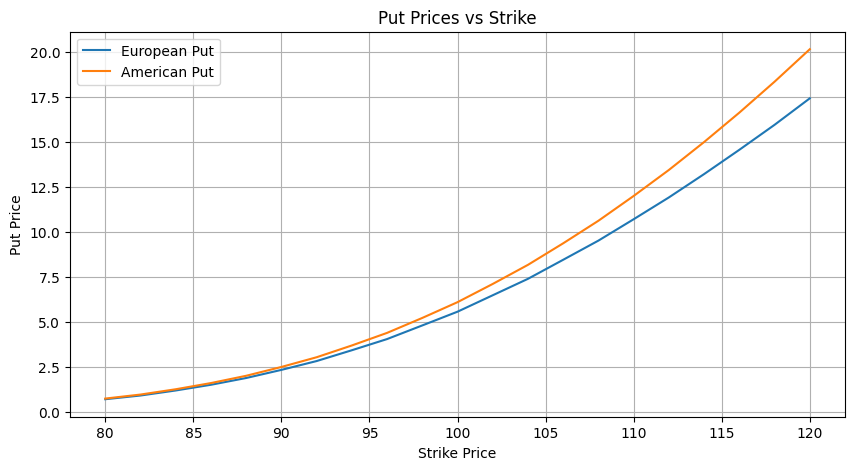

In [44]:
eur_put_K = []
am_put_K = []
for K_val in strike_range:
    eur_put_K.append(binomial_tree_european(S0, K_val, T, r, sigma, N, 'put'))
    am_put_K.append(binomial_tree_american(S0, K_val, T, r, sigma, N, 'put'))

plt.figure(figsize=(10,5))
plt.plot(strike_range, eur_put_K, label='European Put')
plt.plot(strike_range, am_put_K, label='American Put')
plt.xlabel('Strike Price')
plt.ylabel('Put Price')
plt.title('Put Prices vs Strike')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
print("Put-Call Parity for European Options (Trinomial Tree)")
parity_diff = []
for i, K_val in enumerate(strikes):
    left = eur_call_prices[i] + K_val * np.exp(-r * T)
    right = eur_put_prices[i] + S0
    diff = left - right
    parity_diff.append(diff)
    print(f"K={K_val}: Call + Ke^(-rT) = {left:.4f}, Put + S0 = {right:.4f}, Diff = {diff:.6f}")

Put-Call Parity for European Options (Trinomial Tree)
K=90: Call + Ke^(-rT) = 102.2986, Put + S0 = 102.2991, Diff = -0.000450
K=95: Call + Ke^(-rT) = 103.7204, Put + S0 = 103.7209, Diff = -0.000450
K=100: Call + Ke^(-rT) = 105.5536, Put + S0 = 105.5540, Diff = -0.000450
K=105: Call + Ke^(-rT) = 107.9082, Put + S0 = 107.9087, Diff = -0.000450
K=110: Call + Ke^(-rT) = 110.6768, Put + S0 = 110.6772, Diff = -0.000450


In [46]:
print("\nPut-Call Parity for American Options (Trinomial Tree)")
for i, K_val in enumerate(strikes):
    left = am_call_prices[i] + K_val * np.exp(-r * T)
    right = am_put_prices[i] + S0
    diff = left - right
    print(f"K={K_val}: Call + Ke^(-rT) = {left:.4f}, Put + S0 = {right:.4f}, Diff = {diff:.6f}")


Put-Call Parity for American Options (Trinomial Tree)
K=90: Call + Ke^(-rT) = 102.2986, Put + S0 = 102.4602, Diff = -0.161545
K=95: Call + Ke^(-rT) = 103.7204, Put + S0 = 104.0136, Diff = -0.293171
K=100: Call + Ke^(-rT) = 105.5536, Put + S0 = 106.0708, Diff = -0.517248
K=105: Call + Ke^(-rT) = 107.9082, Put + S0 = 108.7354, Diff = -0.827117
K=110: Call + Ke^(-rT) = 110.6768, Put + S0 = 111.9640, Diff = -1.287191


In [47]:
# Parameters
S0_q25 = 180
K_q25 = 182
r_q25 = 0.02
sigma_q25 = 0.25
T_q25 = 0.5
N_q25 = 3
dt_q25 = T_q25 / N_q25
u_q25 = np.exp(sigma_q25 * np.sqrt(dt_q25))
d_q25 = 1 / u_q25
p_q25 = (np.exp(r_q25 * dt_q25) - d_q25) / (u_q25 - d_q25)
discount_q25 = np.exp(-r_q25 * dt_q25)

# Build tree for stock prices
S_tree = np.zeros((N_q25+1, N_q25+1))
for i in range(N_q25+1):
    for j in range(i+1):
        S_tree[i][j] = S0_q25 * (u_q25 ** (i-j)) * (d_q25 ** j)

# Compute European put values at each node (backward)
V_tree = np.zeros((N_q25+1, N_q25+1))
# At maturity
for j in range(N_q25+1):
    V_tree[N_q25][j] = max(K_q25 - S_tree[N_q25][j], 0)
# Backward
for i in range(N_q25-1, -1, -1):
    for j in range(i+1):
        V_tree[i][j] = discount_q25 * (p_q25 * V_tree[i+1][j] + (1-p_q25) * V_tree[i+1][j+1])

print("European Put Price (3-step):", V_tree[0][0].round(2))

# Choose a path: e.g., Up, Up, Down (UUD)
# Path: start at (0,0) -> (1,0) up -> (2,0) up -> (3,1) down
path = [(0,0), (1,0), (2,0), (3,1)]  # indices (step, down moves)
# Compute delta at each node: delta = (V_up - V_down)/(S_up - S_down)
# At each node, we need values at next step children
deltas = []
for idx in range(len(path)-1):
    i, j = path[idx]
    S_curr = S_tree[i][j]
    # children: up child at (i+1, j) and down child at (i+1, j+1)
    V_up = V_tree[i+1][j]
    V_down = V_tree[i+1][j+1]
    S_up = S_tree[i+1][j]
    S_down = S_tree[i+1][j+1]
    delta = (V_up - V_down) / (S_up - S_down)
    deltas.append(delta)

print("Deltas along path UUD:", [round(d,4) for d in deltas])

# Hedging simulation: seller of put (short put). We need to buy delta shares to hedge.
# Cash account evolution: start with cash from selling option, then adjust.
option_price = V_tree[0][0]
cash = option_price  # initial cash from selling option
shares = deltas[0]   # initial hedge (buy shares)
print(f"\nInitial: Sell put for {option_price:.2f}, buy {shares:.4f} shares at S={S0_q25:.2f}, cash = {cash:.2f}")
# Step 1: after first move (up)
S1 = S_tree[1][0]
cash = cash * np.exp(r_q25 * dt_q25) - shares * (S1 - S0_q25)  # adjust for p&l on shares? Actually we need to update cash after price change and then re-hedge.
# Standard approach: at each step, we have cash from previous period plus interest, then we adjust shares.
# Let's follow the slide format: At time 0, we sell put, receive premium, buy delta shares. Cash = premium - delta*S0? Actually we need to set up a self-financing portfolio.
# Typically, we start with a portfolio that is short the option and long delta shares. The cash account is the amount in the money market.
# At time 0: cash = option price - delta * S0 (since we borrow to buy shares? Actually if we sell option, we receive premium. Then we buy delta shares, so we spend delta*S0. Net cash = premium - delta*S0. If positive, we deposit at risk-free rate.
# Let's define cash as money market balance. At time 0, cash = option_price - delta * S0. Then we adjust.
# We'll do step by step.
cash0 = option_price - deltas[0] * S0_q25
print(f"Time 0: cash = {cash0:.4f} (option premium {option_price:.2f} minus {deltas[0]*S0_q25:.2f} for shares)")
# After first step, stock moves to S1. Value of shares = deltas[0] * S1. Cash grows to cash0 * exp(r*dt). Then we need to re-hedge to new delta.
# At time 1, before re-hedging, portfolio value = cash0*exp(r*dt) + deltas[0]*S1. We want to have new delta deltas[1]. So we adjust shares: buy (deltas[1] - deltas[0]) shares at price S1. This changes cash.
cash1_before = cash0 * np.exp(r_q25 * dt_q25)
portfolio_value = cash1_before + deltas[0] * S1
# After re-hedging, we want shares = deltas[1], so we need to spend (deltas[1] - deltas[0]) * S1 from cash.
cash1_after = cash1_before - (deltas[1] - deltas[0]) * S1
print(f"Time 1 (after up move): S={S1:.2f}, old delta={deltas[0]:.4f}, new delta={deltas[1]:.4f}, cash before={cash1_before:.4f}, cash after={cash1_after:.4f}")
# Next step: up again
S2 = S_tree[2][0]
cash2_before = cash1_after * np.exp(r_q25 * dt_q25)
cash2_after = cash2_before - (deltas[2] - deltas[1]) * S2
print(f"Time 2 (up): S={S2:.2f}, new delta={deltas[2]:.4f}, cash before={cash2_before:.4f}, cash after={cash2_after:.4f}")
# Final step: down
S3 = S_tree[3][1]
cash3_before = cash2_after * np.exp(r_q25 * dt_q25)
# At maturity, we need to close position: option payoff = max(K-S3,0). As seller, we pay that. Also we sell shares.
payoff = max(K_q25 - S3, 0)
final_cash = cash3_before + deltas[2] * S3 - payoff  # we have shares, we sell them at S3, and pay option payoff
print(f"Time 3 (down): S={S3:.2f}, payoff={payoff:.2f}, cash before={cash3_before:.4f}, final cash={final_cash:.4f}")
# Ideally final cash should be zero if hedging perfect.

European Put Price (3-step): 13.82
Deltas along path UUD: [np.float64(-0.4726), np.float64(-0.2423), np.float64(0.0)]

Initial: Sell put for 13.82, buy -0.4726 shares at S=180.00, cash = 13.82
Time 0: cash = 98.8821 (option premium 13.82 minus -85.06 for shares)
Time 1 (after up move): S=199.34, old delta=-0.4726, new delta=-0.2423, cash before=99.2123, cash after=53.3199
Time 2 (up): S=220.76, new delta=0.0000, cash before=53.4979, cash after=0.0000
Time 3 (down): S=199.34, payoff=0.00, cash before=0.0000, final cash=0.0000


In [48]:
# Parameters
N_q26 = 25
dt_q26 = T_q25 / N_q26
u_q26 = np.exp(sigma_q25 * np.sqrt(dt_q26))
d_q26 = 1 / u_q26
p_q26 = (np.exp(r_q25 * dt_q26) - d_q26) / (u_q26 - d_q26)
discount_q26 = np.exp(-r_q25 * dt_q26)

# Build stock tree and option value tree for American put
S_tree26 = np.zeros((N_q26+1, N_q26+1))
V_tree26 = np.zeros((N_q26+1, N_q26+1))
for i in range(N_q26+1):
    for j in range(i+1):
        S_tree26[i][j] = S0_q25 * (u_q26 ** (i-j)) * (d_q26 ** j)

# At maturity
for j in range(N_q26+1):
    V_tree26[N_q26][j] = max(K_q25 - S_tree26[N_q26][j], 0)

# Backward induction with early exercise
for i in range(N_q26-1, -1, -1):
    for j in range(i+1):
        continuation = discount_q26 * (p_q26 * V_tree26[i+1][j] + (1-p_q26) * V_tree26[i+1][j+1])
        exercise = max(K_q25 - S_tree26[i][j], 0)
        V_tree26[i][j] = max(continuation, exercise)

print(f"American Put Price (25-step): {V_tree26[0][0]:.2f}")

# Compute delta at each node (using finite difference or tree)
# We'll compute delta as (V_up - V_down)/(S_up - S_down) at each node
delta_tree = np.zeros((N_q26, N_q26))  # deltas at nodes before last step
for i in range(N_q26):
    for j in range(i+1):
        S_up = S_tree26[i+1][j]
        S_down = S_tree26[i+1][j+1]
        V_up = V_tree26[i+1][j]
        V_down = V_tree26[i+1][j+1]
        delta_tree[i][j] = (V_up - V_down) / (S_up - S_down)

# Choose a path, e.g., random path? Let's simulate a path using risk-neutral probabilities.
np.random.seed(42)
path_idx = []  # list of j indices at each step
j = 0
for i in range(N_q26):
    # at step i, current j. Next step: if random < p, up (j unchanged), else down (j+1)
    if np.random.random() < p_q26:
        # up
        path_idx.append(j)
    else:
        j += 1
        path_idx.append(j)
# Now we have j at each step from 1 to N (since at step0 j=0). Let's construct list of nodes: (i, j_i)
nodes = [(0,0)]
for i in range(1, N_q26+1):
    nodes.append((i, path_idx[i-1]))
# Deltas at each step before last: at node i, we have delta from that node to next
deltas_path = [delta_tree[i][nodes[i][1]] for i in range(N_q26)]  # nodes[i] is at step i, delta to step i+1

# Simulate hedging as before
cash = V_tree26[0][0] - deltas_path[0] * S0_q25
print(f"\nHedging American Put along chosen path")
print(f"Step 0: S={S_tree26[0][0]:.2f}, delta={deltas_path[0]:.4f}, cash={cash:.4f}")
S_prev = S0_q25
for i in range(1, N_q26+1):
    S_curr = S_tree26[i][nodes[i][1]]
    # Cash grows
    cash = cash * np.exp(r_q25 * dt_q26)
    # Re-hedge at step i-1? Actually we adjust at beginning of each period. At step i, we have just moved, and we need to set new delta for next period.
    if i < N_q26:
        new_delta = deltas_path[i]
        # Adjust shares: we had old delta from previous step, now need new delta
        old_delta = deltas_path[i-1]
        cash = cash - (new_delta - old_delta) * S_curr
        print(f"Step {i}: S={S_curr:.2f}, old delta={old_delta:.4f}, new delta={new_delta:.4f}, cash after rehedge={cash:.4f}")
    else:
        # final step: payoff
        payoff = max(K_q25 - S_curr, 0)
        cash = cash + deltas_path[i-1] * S_curr - payoff
        print(f"Step {i} (maturity): S={S_curr:.2f}, payoff={payoff:.2f}, final cash={cash:.4f}")

American Put Price (25-step): 13.04

Hedging American Put along chosen path
Step 0: S=180.00, delta=-0.4756, cash=98.6359
Step 1: S=186.48, old delta=-0.4756, new delta=-0.3951, cash after rehedge=83.6739
Step 2: S=180.00, old delta=-0.3951, new delta=-0.4786, cash after rehedge=98.7406
Step 3: S=173.75, old delta=-0.4786, new delta=-0.5675, cash after rehedge=114.2252
Step 4: S=167.71, old delta=-0.5675, new delta=-0.6582, cash after rehedge=129.4810
Step 5: S=173.75, old delta=-0.6582, new delta=-0.5750, cash after rehedge=115.0701
Step 6: S=180.00, old delta=-0.5750, new delta=-0.4856, cash after rehedge=99.0229
Step 7: S=186.48, old delta=-0.4856, new delta=-0.3932, cash after rehedge=81.8468
Step 8: S=180.00, old delta=-0.3932, new delta=-0.4896, cash after rehedge=99.2237
Step 9: S=173.75, old delta=-0.4896, new delta=-0.5931, cash after rehedge=117.2476
Step 10: S=167.71, old delta=-0.5931, new delta=-0.6980, cash after rehedge=134.8890
Step 11: S=173.75, old delta=-0.6980, new 

In [49]:
# Parameters for Asian
N_asian = 5
dt_asian = T_q25 / N_asian
u_asian = np.exp(sigma_q25 * np.sqrt(dt_asian))
d_asian = 1 / u_asian
p_asian = (np.exp(r_q25 * dt_asian) - d_asian) / (u_asian - d_asian)
discount_asian = np.exp(-r_q25 * dt_asian)
K_asian = 180  # ATM

# Generate all paths (list of sequences of up/down)
def generate_paths(step, current_price, path_so_far, paths):
    if step == N_asian:
        paths.append(path_so_far + [current_price])
    else:
        # up
        generate_paths(step+1, current_price * u_asian, path_so_far + [current_price], paths)
        # down
        generate_paths(step+1, current_price * d_asian, path_so_far + [current_price], paths)

paths = []
generate_paths(0, S0_q25, [], paths)
# Each path is list of prices at times 0,1,...,N? Actually we started at step 0 with current_price, and then add to path_so_far. So path_so_far includes price at step 0? Let's adjust: We want prices at each step including initial? For average we might exclude initial. Let's define path as prices from step 1 to N. We'll modify.
# Better: generate paths of returns. We'll just compute using loops.
# Simpler: enumerate all sequences of up/down.
import itertools
moves = list(itertools.product([0,1], repeat=N_asian))  # 0=down, 1=up
prices_paths = []
for move in moves:
    S = S0_q25
    path_prices = []
    for m in move:
        if m == 1:
            S *= u_asian
        else:
            S *= d_asian
        path_prices.append(S)
    prices_paths.append(path_prices)

# Compute Asian put price as average discounted payoff
payoffs = []
for path in prices_paths:
    avg = np.mean(path)
    payoff = max(K_asian - avg, 0)
    payoffs.append(payoff)
asian_price = np.mean(payoffs) * np.exp(-r_q25 * T_q25)  # discount back
print(f"Asian ATM Put Price (5-step, 32 paths): {asian_price:.2f}")

# For delta hedging, we need to compute option value at each node for a given path.
# We'll implement a recursive function that returns value given current step, current stock, and sum of past prices (excluding current?).
# Let sum_so_far be sum of prices from step 1 to current step (i.e., up to now). At step i (0 to N-1), we have observed i prices (since step 1 to i). At step 0, sum_so_far=0.
# At step i, we have current stock S, and we know the future steps. We'll compute value by recursion.

def asian_value(step, S, sum_so_far):
    """step: current time index (0 to N-1). At step 0, we haven't observed any price yet (future prices will be observed at step 1..N)."""
    if step == N_asian:
        # At final step, we have observed all N prices? Actually at step N, we have observed N prices (step 1 to N). But here step is the number of steps taken? Let's define step as number of steps already taken (i.e., we are at time step * dt). Then at step i, we have observed i prices (from step 1 to i). So at step N, we have observed N prices. Then payoff = max(K - (sum_so_far/N), 0).
        return max(K_asian - sum_so_far / N_asian, 0)
    else:
        # Next step: up and down
        S_up = S * u_asian
        S_down = S * d_asian
        # For up move, new sum_so_far becomes sum_so_far + S_up? Actually we add the price at next step.
        V_up = asian_value(step+1, S_up, sum_so_far + S_up)
        V_down = asian_value(step+1, S_down, sum_so_far + S_down)
        return discount_asian * (p_asian * V_up + (1-p_asian) * V_down)

# Compute price at time 0:
asian_price_rec = asian_value(0, S0_q25, 0)
print(f"Asian price via recursion: {asian_price_rec:.2f}")  # Should match

# Now pick a path, e.g., all ups? Let's choose a specific sequence: U,U,U,U,U (all up)
path_moves = [1]*N_asian
S_path = [S0_q25]
for m in path_moves:
    if m==1:
        S_path.append(S_path[-1]*u_asian)
    else:
        S_path.append(S_path[-1]*d_asian)
S_path = S_path[1:]  # prices at steps 1..N

# To compute delta at each node along this path, we need the option value at that node given the sum so far.
# We'll compute delta as (V_up - V_down)/(S_up - S_down) at each node.
deltas_asian = []
sum_so_far = 0
S_curr = S0_q25
for step in range(N_asian):
    # At current node (step, S_curr, sum_so_far), we need values at next step for up and down.
    # But note: sum_so_far is sum of prices from step 1 to step (i.e., up to now). For step=0, sum_so_far=0.
    # Next step: up and down.
    S_up = S_curr * u_asian
    S_down = S_curr * d_asian
    # For up, new sum = sum_so_far + S_up (since we will observe that price at next step)
    # For down, new sum = sum_so_far + S_down
    V_up = asian_value(step+1, S_up, sum_so_far + S_up)
    V_down = asian_value(step+1, S_down, sum_so_far + S_down)
    delta = (V_up - V_down) / (S_up - S_down)
    deltas_asian.append(delta)
    # Then move along path: next S_curr is the actual next price from our path
    next_S = S_path[step]
    # Update sum_so_far by adding the actual next price (since we will have observed it)
    sum_so_far += next_S
    S_curr = next_S

print(f"Deltas along all-up path: {[round(d,4) for d in deltas_asian]}")

# Hedging simulation similar to before but with these deltas
cash = asian_price_rec - deltas_asian[0] * S0_q25
print(f"\nHedging Asian Put along all-up path")
print(f"Step 0: S={S0_q25:.2f}, delta={deltas_asian[0]:.4f}, cash={cash:.4f}")
S_prev = S0_q25
for i in range(1, N_asian+1):
    S_curr = S_path[i-1]
    cash = cash * np.exp(r_q25 * dt_asian)
    if i < N_asian:
        new_delta = deltas_asian[i]
        old_delta = deltas_asian[i-1]
        cash = cash - (new_delta - old_delta) * S_curr
        print(f"Step {i}: S={S_curr:.2f}, old delta={old_delta:.4f}, new delta={new_delta:.4f}, cash after={cash:.4f}")
    else:
        # final step: payoff based on average of all S_path (which we have)
        avg = np.mean(S_path)
        payoff = max(K_asian - avg, 0)
        cash = cash + deltas_asian[i-1] * S_curr - payoff
        print(f"Step {i} (maturity): S={S_curr:.2f}, avg={avg:.2f}, payoff={payoff:.2f}, final cash={cash:.4f}")

Asian ATM Put Price (5-step, 32 paths): 7.85
Asian price via recursion: 8.12
Deltas along all-up path: [np.float64(-0.4605), np.float64(-0.0952), np.float64(0.0), np.float64(0.0), np.float64(0.0)]

Hedging Asian Put along all-up path
Step 0: S=180.00, delta=-0.4605, cash=91.0135
Step 1: S=194.81, old delta=-0.4605, new delta=-0.0952, cash after=20.0269
Step 2: S=210.83, old delta=-0.0952, new delta=0.0000, cash after=-0.0000
Step 3: S=228.18, old delta=0.0000, new delta=0.0000, cash after=-0.0000
Step 4: S=246.95, old delta=0.0000, new delta=0.0000, cash after=-0.0000
Step 5 (maturity): S=267.27, avg=229.61, payoff=0.00, final cash=-0.0000
